# P0v2 — Branch-Conditional P(t): Host for TIP-INT, GPU for INT-INT

Verifying **P0v2** (branch-conditional P(t) computation) against:
- **GPU P0** — previous P0 (unconditional GPU P(t) + update self download)
- **GPU P5** — original GPU baseline (persistent tip states)
- **CPU backends**: OMP_48, OMP_10, VANILA

P0v2 fixes the DNA/GTR regression in P0 by splitting P(t) computation:
- **TIP-INTERNAL**: Host-side `model->computeTransDerv()` + `update device` (no download)
- **INTERNAL-INTERNAL**: GPU kernel `computeTransDerivOnGPU()` (no host copy needed)

This eliminates the expensive `update self()` GPU→host download that caused ~0.3%
regression on DNA/GTR in the original P0.

Models: AA/LG and DNA/GTR (unrooted), 100 taxa, 1M sites, 10 runs each

**Focus: DNA/GTR regression fixed? + AA/LG unchanged? + correctness**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120

P0V2_DIR = Path('/Users/u7826985/Projects/Nvidia/results/2026_03_14_p1fixdna')
P0_DIR = Path('/Users/u7826985/Projects/Nvidia/results/2026_03_14_p1fixagain')
P5_DIR = Path('/Users/u7826985/Projects/Nvidia/results/2026_03_13_persistent_tip_state')
BASELINE_DIR = Path('/Users/u7826985/Projects/Nvidia/results/2026_03_13_branch_length_estimation')
SAVE_DIR = Path('.')

## 1. Parse All Log Files

In [2]:
def parse_log(filepath):
    try:
        with open(filepath, 'r') as f:
            text = f.read()
    except Exception:
        return None
    result = {}
    m = re.search(r'Total wall-clock time used:\s+([\d.]+)\s+sec', text)
    if m: result['walltime'] = float(m.group(1))
    m = re.search(r'Total CPU time used:\s+([\d.]+)\s+sec', text)
    if m: result['cputime'] = float(m.group(1))
    m = re.search(r'BEST SCORE FOUND\s*:\s*([\-\d.]+)', text)
    if m: result['log_likelihood'] = float(m.group(1))
    m = re.search(r'Total tree length:\s+([\d.]+)', text)
    if m: result['tree_length'] = float(m.group(1))
    m = re.search(r'Parameters optimization took \d+ rounds \(([\d.]+) sec\)', text)
    if m: result['opt_time'] = float(m.group(1))
    m = re.search(r'Parameters optimization took (\d+) rounds', text)
    if m: result['opt_rounds'] = int(m.group(1))
    m = re.search(r'Initial log-likelihood:.*?\(took\s+([\d.]+)\s+wall-clock sec\)', text)
    if m: result['first_eval_sec'] = float(m.group(1))
    result['n_underflow'] = len(re.findall(r'Numerical underflow', text))
    return result if 'walltime' in result else None

def extract_run_number(filename):
    matches = re.findall(r'_run(\d+)_', filename)
    return int(matches[-1]) if matches else None

def classify_backend(filename):
    if 'OPENACC' in filename: return 'OPENACC'
    elif 'VANILA' in filename: return 'VANILA'
    elif 'OMP_48' in filename: return 'OMP_48'
    elif 'OMP_10' in filename: return 'OMP_10'
    return 'UNKNOWN'

def parse_results_dir(base_dir, backend_override=None, skip_profile=True):
    rows = []
    for data_type in ['AA', 'DNA']:
        for tree_type in ['rooted', 'unrooted']:
            type_dir = base_dir / data_type / tree_type
            if not type_dir.exists(): continue
            for model_dir in sorted(type_dir.iterdir()):
                if not model_dir.is_dir(): continue
                model = model_dir.name
                for tree_dir in sorted(model_dir.iterdir()):
                    if not tree_dir.is_dir(): continue
                    tree = tree_dir.name
                    for logfile in tree_dir.glob('*.log'):
                        fname = logfile.name
                        if skip_profile and 'profile' in fname.lower(): continue
                        backend = backend_override if backend_override else classify_backend(fname)
                        run_num = extract_run_number(fname)
                        metrics = parse_log(logfile)
                        if metrics:
                            rows.append({'data_type': data_type, 'tree_type': tree_type,
                                        'model': model, 'tree': tree, 'backend': backend,
                                        'run': run_num, 'filename': fname, **metrics})
    return rows

In [3]:
# Parse P0v2 results (branch-conditional P(t))
rows_p0v2 = parse_results_dir(P0V2_DIR, backend_override='GPU_P0v2')
df_p0v2 = pd.DataFrame(rows_p0v2)
print(f'P0v2: {len(df_p0v2)} entries')
print(df_p0v2.groupby(['data_type', 'backend']).size())

# Check for underflow warnings
total_underflow = df_p0v2['n_underflow'].sum()
print(f'\nTotal numerical underflow warnings across all runs: {total_underflow}')
if total_underflow == 0:
    print('  \u2705 No numerical underflow warnings — P0v2 is numerically stable.')
else:
    print('  \u274c WARNING: Numerical underflow detected!')
    print(df_p0v2[df_p0v2['n_underflow'] > 0][['data_type', 'tree', 'run', 'n_underflow']])

# Parse P0 (previous, unconditional GPU P(t))
rows_p0 = parse_results_dir(P0_DIR, backend_override='GPU_P0')
df_p0 = pd.DataFrame(rows_p0)
print(f'\nGPU P0 (previous): {len(df_p0)} entries')

# Parse P5 baseline
rows_p5 = parse_results_dir(P5_DIR, backend_override='GPU_P5')
df_p5 = pd.DataFrame(rows_p5)
print(f'GPU P5 (baseline): {len(df_p5)} entries')

# Parse CPU baselines
rows_base = parse_results_dir(BASELINE_DIR)
df_base = pd.DataFrame(rows_base)
df_base = df_base[
    (df_base['tree_type'] == 'unrooted') &
    (((df_base['data_type'] == 'AA') & (df_base['model'] == 'LG')) |
     ((df_base['data_type'] == 'DNA') & (df_base['model'] == 'GTR')))
].copy()
df_cpu = df_base[df_base['backend'].isin(['VANILA', 'OMP_10', 'OMP_48'])].copy()
print(f'CPU baselines: {len(df_cpu)} entries')

# Combine
df = pd.concat([df_cpu, df_p5, df_p0, df_p0v2], ignore_index=True)
df['overhead'] = df['walltime'] - df['opt_time']
df.to_csv(SAVE_DIR / 'results_all.csv', index=False)

print(f'\nCombined: {len(df)} entries')
print(df.groupby(['data_type', 'backend']).size().unstack(fill_value=0))

P0v2: 178 entries
data_type  backend 
AA         GPU_P0v2    98
DNA        GPU_P0v2    80
dtype: int64

Total numerical underflow warnings across all runs: 0
  ✅ No numerical underflow warnings — P0v2 is numerically stable.



GPU P0 (previous): 175 entries


GPU P5 (baseline): 179 entries


CPU baselines: 460 entries

Combined: 992 entries
backend    GPU_P0  GPU_P0v2  GPU_P5  OMP_10  OMP_48  VANILA
data_type                                                  
AA             96        98      99     100     100      20
DNA            79        80      80     100     100      40


## 2. Likelihood Verification (Critical Correctness Check)

In [4]:
# Per-tree, per-backend likelihood
logl_detail = df.groupby(['data_type', 'model', 'tree', 'backend']).agg(
    logl_mean=('log_likelihood', 'mean'),
    logl_std=('log_likelihood', 'std'),
    n=('log_likelihood', 'count')
).round(6).reset_index()
logl_detail.to_csv(SAVE_DIR / 'likelihood_per_tree_backend.csv', index=False)

logl_pivot = logl_detail.pivot_table(index=['data_type', 'model', 'tree'],
                                      columns='backend', values='logl_mean').reset_index()

# Likelihood differences: GPU_P0v2 vs every other backend
diff_cols = []
for b in ['VANILA', 'OMP_10', 'OMP_48', 'GPU_P5', 'GPU_P0']:
    if b in logl_pivot.columns and 'GPU_P0v2' in logl_pivot.columns:
        col = f'P0v2_minus_{b}'
        logl_pivot[col] = (logl_pivot['GPU_P0v2'] - logl_pivot[b]).round(6)
        diff_cols.append(col)

print('Likelihood differences (GPU_P0v2 - other backend):')
print('0.0 = identical, NaN = tree not present in that backend')
display(logl_pivot[['data_type', 'model', 'tree'] + diff_cols])
logl_pivot.to_csv(SAVE_DIR / 'likelihood_comparison.csv', index=False)

# Summary of differences
print('\n=== Difference Summary ===')
for col in diff_cols:
    vals = logl_pivot[col].dropna()
    print(f'  {col}: min={vals.min():.6f}  max={vals.max():.6f}  '
          f'mean={vals.mean():.6f}  all_zero={all(vals == 0.0)}')

Likelihood differences (GPU_P0v2 - other backend):
0.0 = identical, NaN = tree not present in that backend


backend,data_type,model,tree,P0v2_minus_VANILA,P0v2_minus_OMP_10,P0v2_minus_OMP_48,P0v2_minus_GPU_P5,P0v2_minus_GPU_P0
0,AA,LG,tree_1,0.0,0.0,0.0,0.0,0.0
1,AA,LG,tree_10,NaN,0.0,0.0,0.0,0.0
2,AA,LG,tree_2,0.0,0.0,0.0,0.0,0.0
3,AA,LG,tree_3,NaN,0.0,0.0,0.0,0.0
4,AA,LG,tree_4,NaN,0.0,0.0,0.0,0.0
5,AA,LG,tree_5,NaN,0.0,0.0,0.0,0.0
6,AA,LG,tree_6,NaN,0.0,0.0,0.0,0.0
7,AA,LG,tree_7,NaN,0.0,0.0,0.0,0.0
8,AA,LG,tree_8,NaN,0.0,0.0,0.0,0.0
9,AA,LG,tree_9,NaN,0.0,0.0,0.0,0.0



=== Difference Summary ===
  P0v2_minus_VANILA: min=0.000000  max=0.000000  mean=0.000000  all_zero=True
  P0v2_minus_OMP_10: min=0.000000  max=0.000000  mean=0.000000  all_zero=True
  P0v2_minus_OMP_48: min=0.000000  max=0.000000  mean=0.000000  all_zero=True
  P0v2_minus_GPU_P5: min=0.000000  max=0.000000  mean=0.000000  all_zero=True
  P0v2_minus_GPU_P0: min=0.000000  max=0.000000  mean=0.000000  all_zero=True


In [5]:
# Overall range check: max log-likelihood difference across ALL backends per tree
logl_range = df.groupby(['data_type', 'model', 'tree']).agg(
    logl_min=('log_likelihood', 'min'),
    logl_max=('log_likelihood', 'max'),
    logl_range=('log_likelihood', lambda x: x.max() - x.min()),
    tl_min=('tree_length', 'min'),
    tl_max=('tree_length', 'max'),
    tl_range=('tree_length', lambda x: x.max() - x.min())
).reset_index()
logl_range.to_csv(SAVE_DIR / 'likelihood_range_check.csv', index=False)

logl_mismatch = logl_range[logl_range['logl_range'] > 0.01]
tl_mismatch = logl_range[logl_range['tl_range'] > 0.001]

print(f'Log-likelihood mismatches (range > 0.01): {len(logl_mismatch)}')
if len(logl_mismatch) > 0:
    display(logl_mismatch)
else:
    print('  \u2705 All backends produce identical log-likelihoods.')

print(f'\nTree length mismatches (range > 0.001): {len(tl_mismatch)}')
if len(tl_mismatch) > 0:
    display(tl_mismatch)
else:
    print('  \u2705 All backends produce identical tree lengths.')

Log-likelihood mismatches (range > 0.01): 0
  ✅ All backends produce identical log-likelihoods.

Tree length mismatches (range > 0.001): 0
  ✅ All backends produce identical tree lengths.


## 3. Performance Summary

In [6]:
summary = df.groupby(['data_type', 'model', 'backend']).agg(
    walltime_median=('walltime', 'median'),
    opt_time_median=('opt_time', 'median'),
    opt_time_std=('opt_time', 'std'),
    overhead_median=('overhead', 'median'),
    n_runs=('walltime', 'count')
).round(3)
summary.to_csv(SAVE_DIR / 'results_summary.csv')

print('=== Time Breakdown (median values) ===')
backend_order = ['VANILA', 'OMP_10', 'OMP_48', 'GPU_P5', 'GPU_P0', 'GPU_P0v2']
for dt in ['AA', 'DNA']:
    print(f'\n--- {dt} ---')
    for b in backend_order:
        sub = df[(df['data_type'] == dt) & (df['backend'] == b)]
        if sub.empty: continue
        print(f"  {b:14s}  walltime={sub['walltime'].median():7.2f}s  "
              f"opt_time={sub['opt_time'].median():7.2f}s  "
              f"overhead={sub['overhead'].median():5.2f}s  "
              f"(n={len(sub)})")

=== Time Breakdown (median values) ===

--- AA ---
  VANILA          walltime= 250.29s  opt_time= 247.28s  overhead= 2.99s  (n=20)
  OMP_10          walltime=  38.56s  opt_time=  37.32s  overhead= 1.28s  (n=100)
  OMP_48          walltime=  15.02s  opt_time=  13.59s  overhead= 1.39s  (n=100)
  GPU_P5          walltime=  18.29s  opt_time=  15.40s  overhead= 2.86s  (n=99)
  GPU_P0          walltime=  18.27s  opt_time=  15.39s  overhead= 2.88s  (n=96)
  GPU_P0v2        walltime=  18.26s  opt_time=  15.38s  overhead= 2.86s  (n=98)

--- DNA ---
  VANILA          walltime= 122.00s  opt_time= 119.26s  overhead= 2.69s  (n=40)
  OMP_10          walltime=  34.24s  opt_time=  33.17s  overhead= 1.08s  (n=100)
  OMP_48          walltime=  15.05s  opt_time=  13.61s  overhead= 1.10s  (n=100)
  GPU_P5          walltime=  23.62s  opt_time=  20.81s  overhead= 2.80s  (n=80)
  GPU_P0          walltime=  23.67s  opt_time=  20.92s  overhead= 2.80s  (n=79)
  GPU_P0v2        walltime=  23.67s  opt_time=  20.8

## 4. P0 vs P0v2 — DNA/GTR Regression Fix

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_19530/423857047.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_19530/423857047.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(p_labels, fontsize=10)
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_19530/423857047.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_19530/423857047.py:36: UserWarning: set_ticklabe

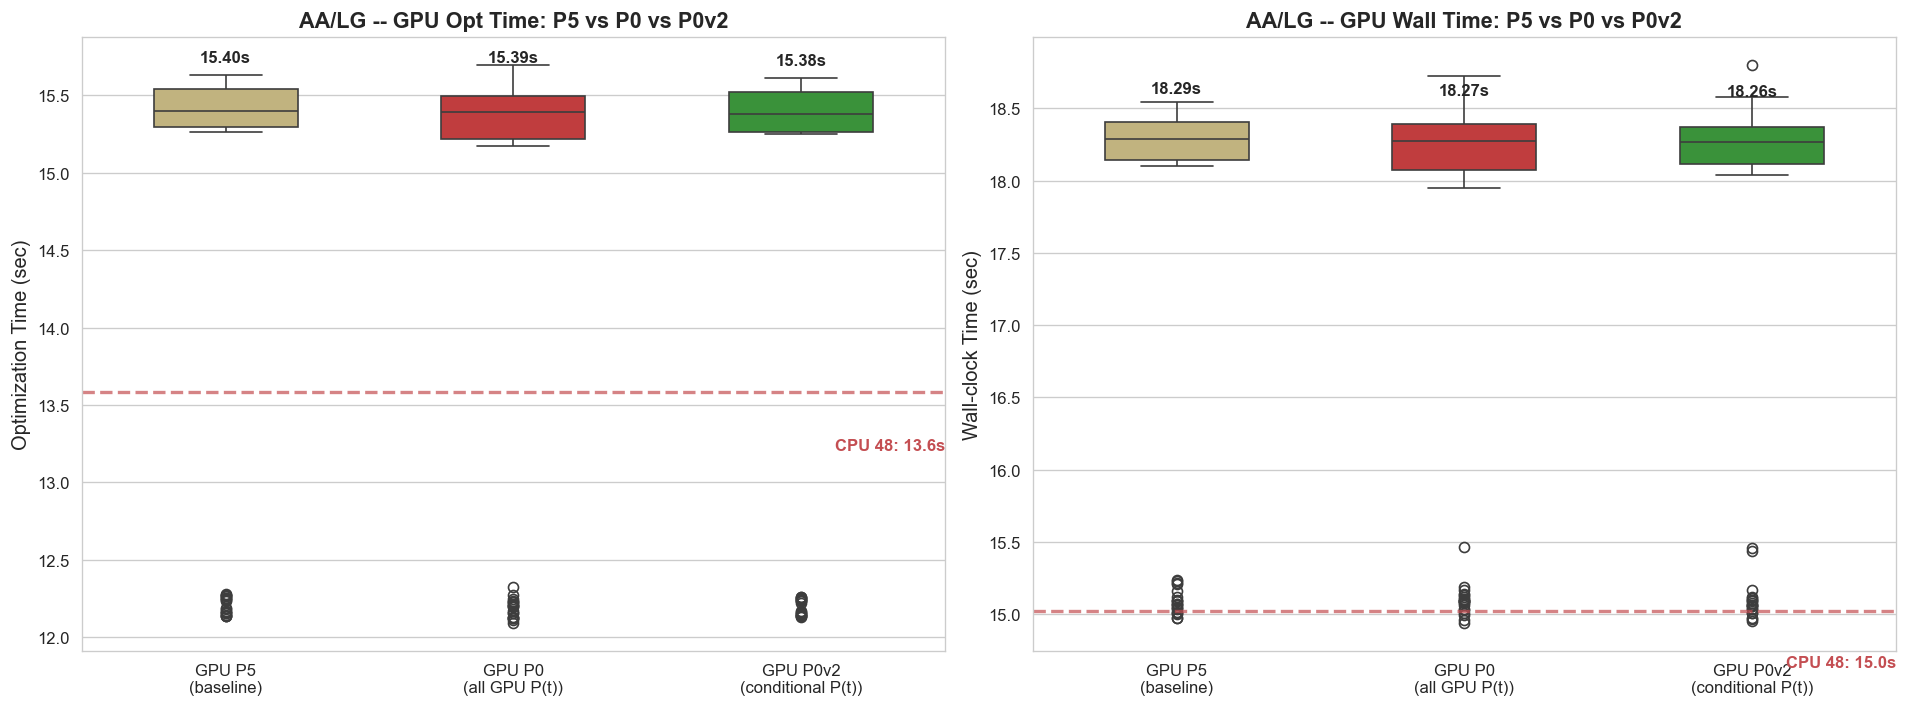

Saved: gpu_p0_vs_p0v2_AA_LG.png


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_19530/423857047.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_19530/423857047.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(p_labels, fontsize=10)
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_19530/423857047.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_19530/423857047.py:36: UserWarning: set_ticklabe

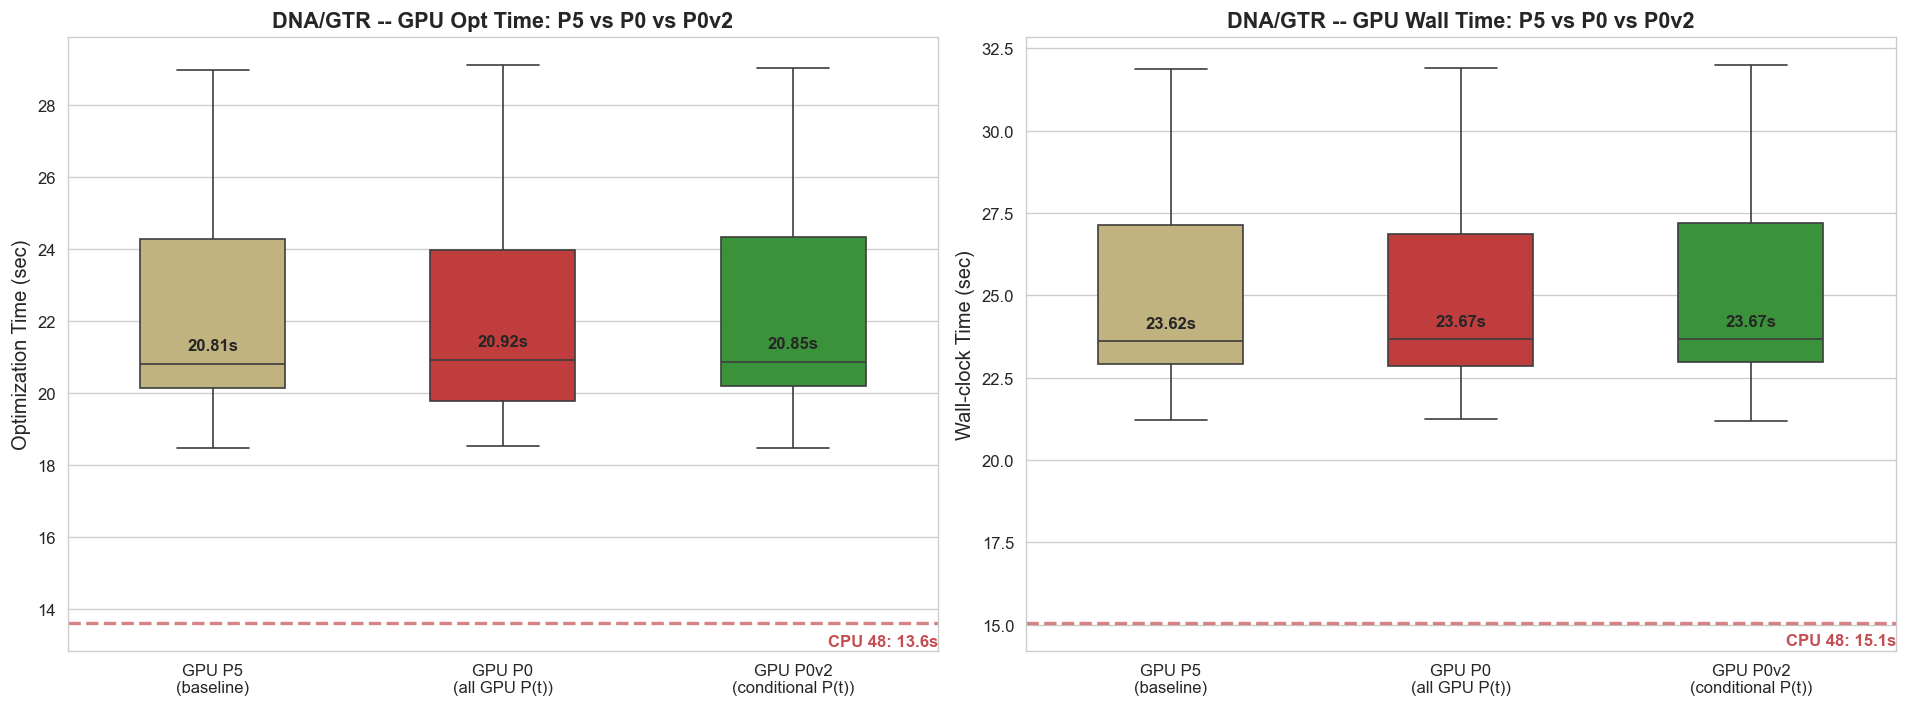

Saved: gpu_p0_vs_p0v2_DNA_GTR.png


In [7]:
gpu_order = ['GPU_P5', 'GPU_P0', 'GPU_P0v2']
gpu_labels = ['GPU P5\n(baseline)', 'GPU P0\n(all GPU P(t))', 'GPU P0v2\n(conditional P(t))']
gpu_colors = ['#CCB974', '#d62728', '#2ca02c']

for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = df[(df['data_type'] == data_type) & (df['model'] == model) &
               df['backend'].isin(gpu_order)]
    present = [b for b in gpu_order if b in subset['backend'].unique()]
    p_colors = [gpu_colors[gpu_order.index(b)] for b in present]
    p_labels = [gpu_labels[gpu_order.index(b)] for b in present]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left: opt_time
    sns.boxplot(data=subset, x='backend', y='opt_time',
               order=present, palette=p_colors, ax=ax1, width=0.5)
    ax1.set_xticklabels(p_labels, fontsize=10)
    ax1.set_ylabel('Optimization Time (sec)', fontsize=12)
    ax1.set_xlabel('')
    ax1.set_title(f'{data_type}/{model} -- GPU Opt Time: P5 vs P0 vs P0v2', fontsize=13, fontweight='bold')
    medians = subset.groupby('backend')['opt_time'].median()
    for i, b in enumerate(present):
        if b in medians.index:
            ax1.text(i, medians[b] + 0.3, f'{medians[b]:.2f}s',
                   ha='center', va='bottom', fontweight='bold', fontsize=10)
    cpu48_opt = df[(df['data_type'] == data_type) & (df['model'] == model) & 
                   (df['backend'] == 'OMP_48')]['opt_time'].median()
    if not np.isnan(cpu48_opt):
        ax1.axhline(y=cpu48_opt, color='#C44E52', linestyle='--', alpha=0.7, linewidth=2)
        ax1.text(len(present) - 0.5, cpu48_opt - 0.3, f'CPU 48: {cpu48_opt:.1f}s',
               fontsize=10, color='#C44E52', fontweight='bold', ha='right', va='top')
    
    # Right: walltime
    sns.boxplot(data=subset, x='backend', y='walltime',
               order=present, palette=p_colors, ax=ax2, width=0.5)
    ax2.set_xticklabels(p_labels, fontsize=10)
    ax2.set_ylabel('Wall-clock Time (sec)', fontsize=12)
    ax2.set_xlabel('')
    ax2.set_title(f'{data_type}/{model} -- GPU Wall Time: P5 vs P0 vs P0v2', fontsize=13, fontweight='bold')
    medians_wt = subset.groupby('backend')['walltime'].median()
    for i, b in enumerate(present):
        if b in medians_wt.index:
            ax2.text(i, medians_wt[b] + 0.3, f'{medians_wt[b]:.2f}s',
                   ha='center', va='bottom', fontweight='bold', fontsize=10)
    cpu48_wt = df[(df['data_type'] == data_type) & (df['model'] == model) & 
                  (df['backend'] == 'OMP_48')]['walltime'].median()
    if not np.isnan(cpu48_wt):
        ax2.axhline(y=cpu48_wt, color='#C44E52', linestyle='--', alpha=0.7, linewidth=2)
        ax2.text(len(present) - 0.5, cpu48_wt - 0.3, f'CPU 48: {cpu48_wt:.1f}s',
               fontsize=10, color='#C44E52', fontweight='bold', ha='right', va='top')
    
    plt.tight_layout()
    fname = f'gpu_p0_vs_p0v2_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 5. Per-Tree Opt Time Comparison

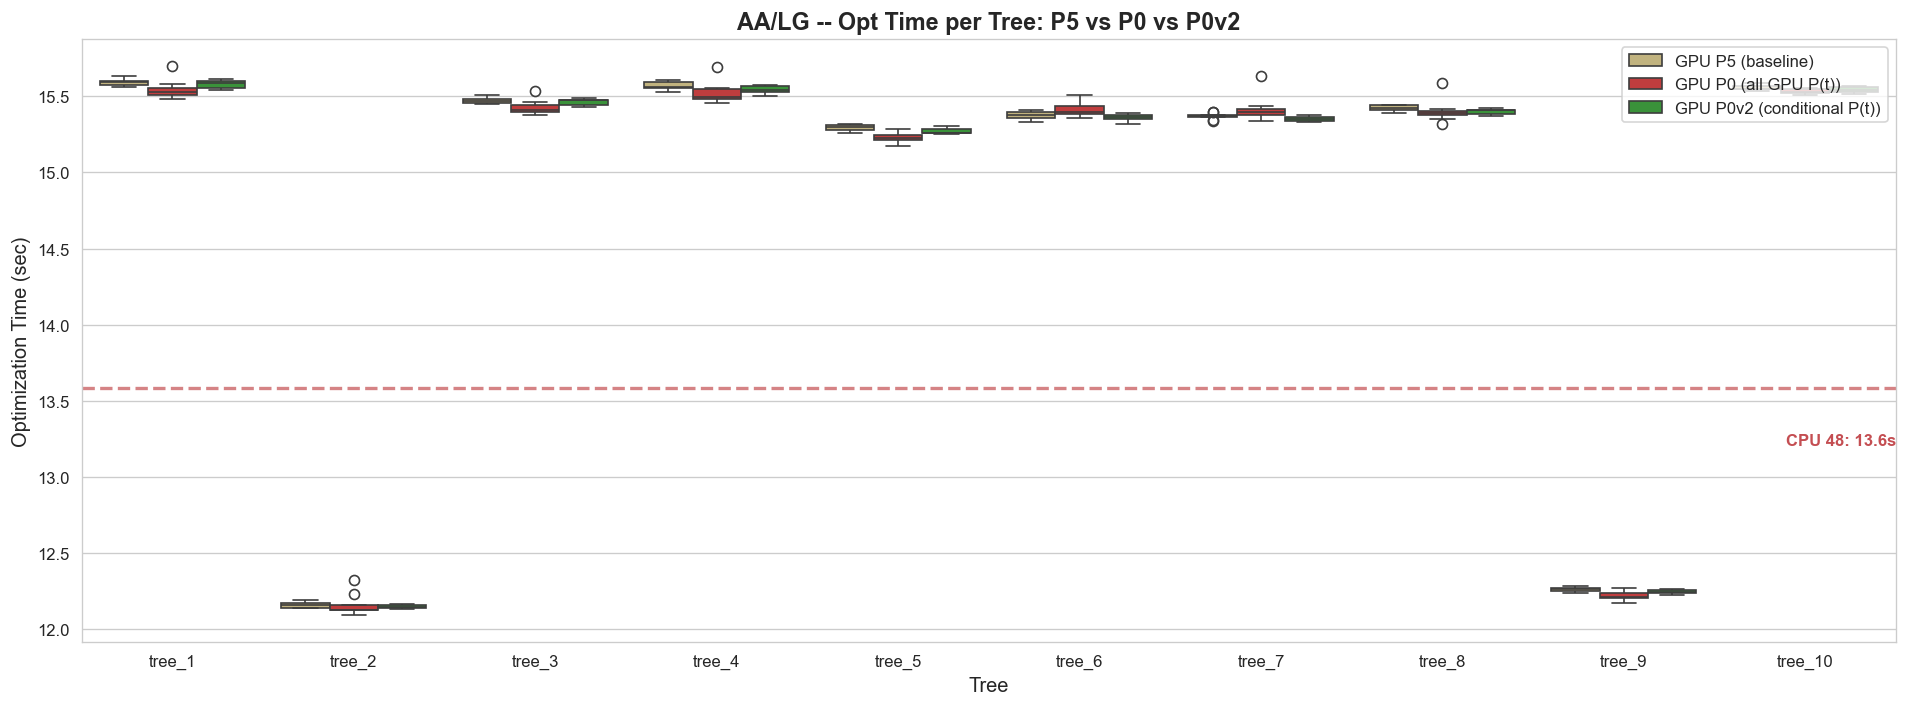

Saved: opt_per_tree_AA_LG.png


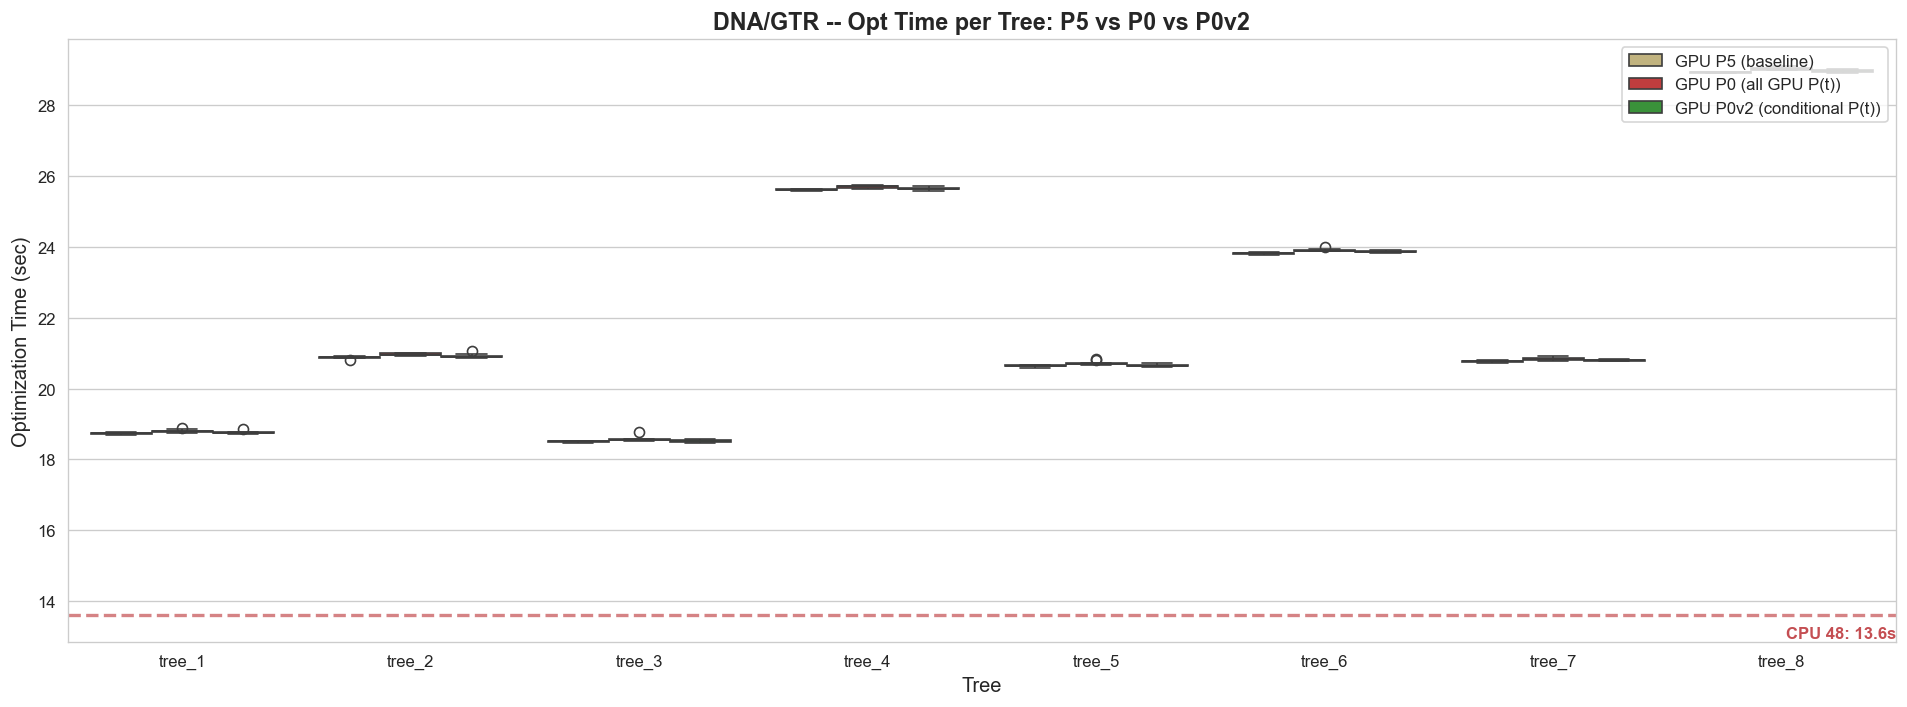

Saved: opt_per_tree_DNA_GTR.png


In [8]:
for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = df[(df['data_type'] == data_type) & (df['model'] == model) &
               df['backend'].isin(['GPU_P5', 'GPU_P0', 'GPU_P0v2'])]
    if subset.empty: continue
    trees = sorted(subset['tree'].unique(), key=lambda x: int(x.split('_')[1]))
    
    fig, ax = plt.subplots(figsize=(16, 6))
    sns.boxplot(data=subset, x='tree', y='opt_time', hue='backend',
               order=trees, hue_order=['GPU_P5', 'GPU_P0', 'GPU_P0v2'],
               palette=['#CCB974', '#d62728', '#2ca02c'],
               ax=ax, width=0.8)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['GPU P5 (baseline)', 'GPU P0 (all GPU P(t))', 'GPU P0v2 (conditional P(t))'],
             fontsize=10, loc='upper right')
    ax.set_xlabel('Tree', fontsize=12)
    ax.set_ylabel('Optimization Time (sec)', fontsize=12)
    ax.set_title(f'{data_type}/{model} -- Opt Time per Tree: P5 vs P0 vs P0v2',
                fontsize=14, fontweight='bold')
    
    cpu48_opt = df[(df['data_type'] == data_type) & (df['model'] == model) & 
                   (df['backend'] == 'OMP_48')]['opt_time'].median()
    if not np.isnan(cpu48_opt):
        ax.axhline(y=cpu48_opt, color='#C44E52', linestyle='--', alpha=0.7, linewidth=2)
        ax.text(len(trees) - 0.5, cpu48_opt - 0.3, f'CPU 48: {cpu48_opt:.1f}s',
               fontsize=10, color='#C44E52', fontweight='bold', ha='right', va='top')
    
    plt.tight_layout()
    fname = f'opt_per_tree_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

In [9]:
# Per-tree improvement table with deltas vs P5 and P0
for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    print(f'\n=== {data_type}/{model} Per-Tree Opt Time (median) ===')
    subset = df[(df['data_type'] == data_type) & (df['model'] == model) &
               df['backend'].isin(['GPU_P5', 'GPU_P0', 'GPU_P0v2'])]
    trees = sorted(subset['tree'].unique(), key=lambda x: int(x.split('_')[1]))
    
    rows = []
    for tree in trees:
        p5_med = subset[(subset['tree'] == tree) & (subset['backend'] == 'GPU_P5')]['opt_time'].median()
        p0_med = subset[(subset['tree'] == tree) & (subset['backend'] == 'GPU_P0')]['opt_time'].median()
        p0v2_med = subset[(subset['tree'] == tree) & (subset['backend'] == 'GPU_P0v2')]['opt_time'].median()
        row = {'tree': tree}
        if not np.isnan(p5_med): row['P5'] = p5_med
        if not np.isnan(p0_med): row['P0'] = p0_med
        if not np.isnan(p0v2_med): row['P0v2'] = p0v2_med
        # Delta vs P5
        if 'P5' in row and 'P0v2' in row:
            row['\u0394_vs_P5_s'] = p0v2_med - p5_med
            row['\u0394_vs_P5_%'] = (p0v2_med - p5_med) / p5_med * 100
        # Delta vs P0
        if 'P0' in row and 'P0v2' in row:
            row['\u0394_vs_P0_s'] = p0v2_med - p0_med
            row['\u0394_vs_P0_%'] = (p0v2_med - p0_med) / p0_med * 100
        rows.append(row)
    
    tree_df = pd.DataFrame(rows)
    tree_df = tree_df.round(3)
    display(tree_df)
    if '\u0394_vs_P5_%' in tree_df.columns:
        print(f'Mean change vs P5: {tree_df["\u0394_vs_P5_%"].mean():.2f}%')
    if '\u0394_vs_P0_%' in tree_df.columns:
        print(f'Mean change vs P0: {tree_df["\u0394_vs_P0_%"].mean():.2f}%')


=== AA/LG Per-Tree Opt Time (median) ===


,tree,P5,P0,P0v2,Δ_vs_P5_s,Δ_vs_P5_%,Δ_vs_P0_s,Δ_vs_P0_%
0,tree_1,15.596,15.525,15.588,-0.008,-0.051,0.064,0.409
1,tree_2,12.157,12.128,12.147,-0.010,-0.082,0.019,0.161
2,tree_3,15.472,15.410,15.472,0.001,0.006,0.062,0.402
3,tree_4,15.561,15.497,15.544,-0.017,-0.109,0.046,0.300
4,tree_5,15.298,15.224,15.262,-0.036,-0.235,0.038,0.246
5,tree_6,15.377,15.396,15.364,-0.013,-0.085,-0.032,-0.208
6,tree_7,15.370,15.394,15.352,-0.018,-0.117,-0.042,-0.273
7,tree_8,15.426,15.388,15.408,-0.017,-0.110,0.021,0.133
8,tree_9,12.260,12.214,12.244,-0.017,-0.135,0.030,0.250
9,tree_10,15.550,15.530,15.544,-0.007,-0.042,0.013,0.084


Mean change vs P5: -0.10%
Mean change vs P0: 0.15%

=== DNA/GTR Per-Tree Opt Time (median) ===


,tree,P5,P0,P0v2,Δ_vs_P5_s,Δ_vs_P5_%,Δ_vs_P0_s,Δ_vs_P0_%
0,tree_1,18.742,18.794,18.742,-0.000,-0.003,-0.052,-0.279
1,tree_2,20.886,20.960,20.900,0.013,0.062,-0.061,-0.291
2,tree_3,18.508,18.554,18.526,0.018,0.097,-0.029,-0.154
3,tree_4,25.618,25.709,25.644,0.026,0.101,-0.065,-0.253
4,tree_5,20.644,20.708,20.651,0.006,0.031,-0.058,-0.278
5,tree_6,23.818,23.900,23.862,0.044,0.183,-0.038,-0.159
6,tree_7,20.772,20.829,20.796,0.024,0.116,-0.033,-0.158
7,tree_8,28.937,29.040,28.971,0.034,0.117,-0.069,-0.238


Mean change vs P5: 0.09%
Mean change vs P0: -0.23%


## 6. Full Backend Comparison

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_19530/3783124834.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_19530/3783124834.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(p_labels, fontsize=10)
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_19530/3783124834.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_19530/3783124834.py:28: UserWarning: set_tick

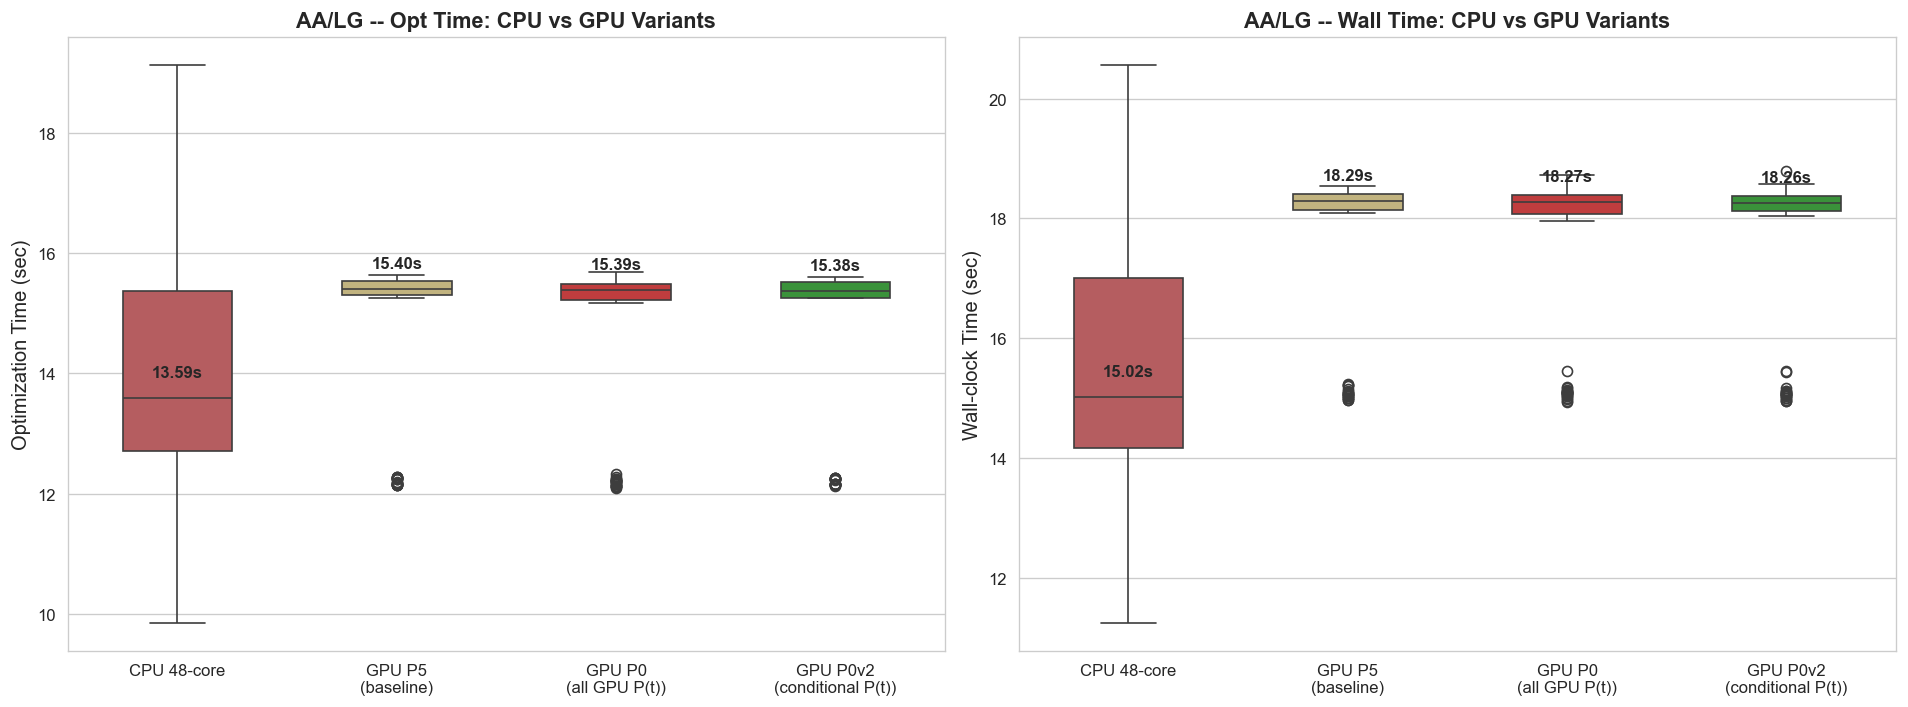

Saved: full_comparison_AA_LG.png


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_19530/3783124834.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_19530/3783124834.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(p_labels, fontsize=10)
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_19530/3783124834.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_19530/3783124834.py:28: UserWarning: set_tick

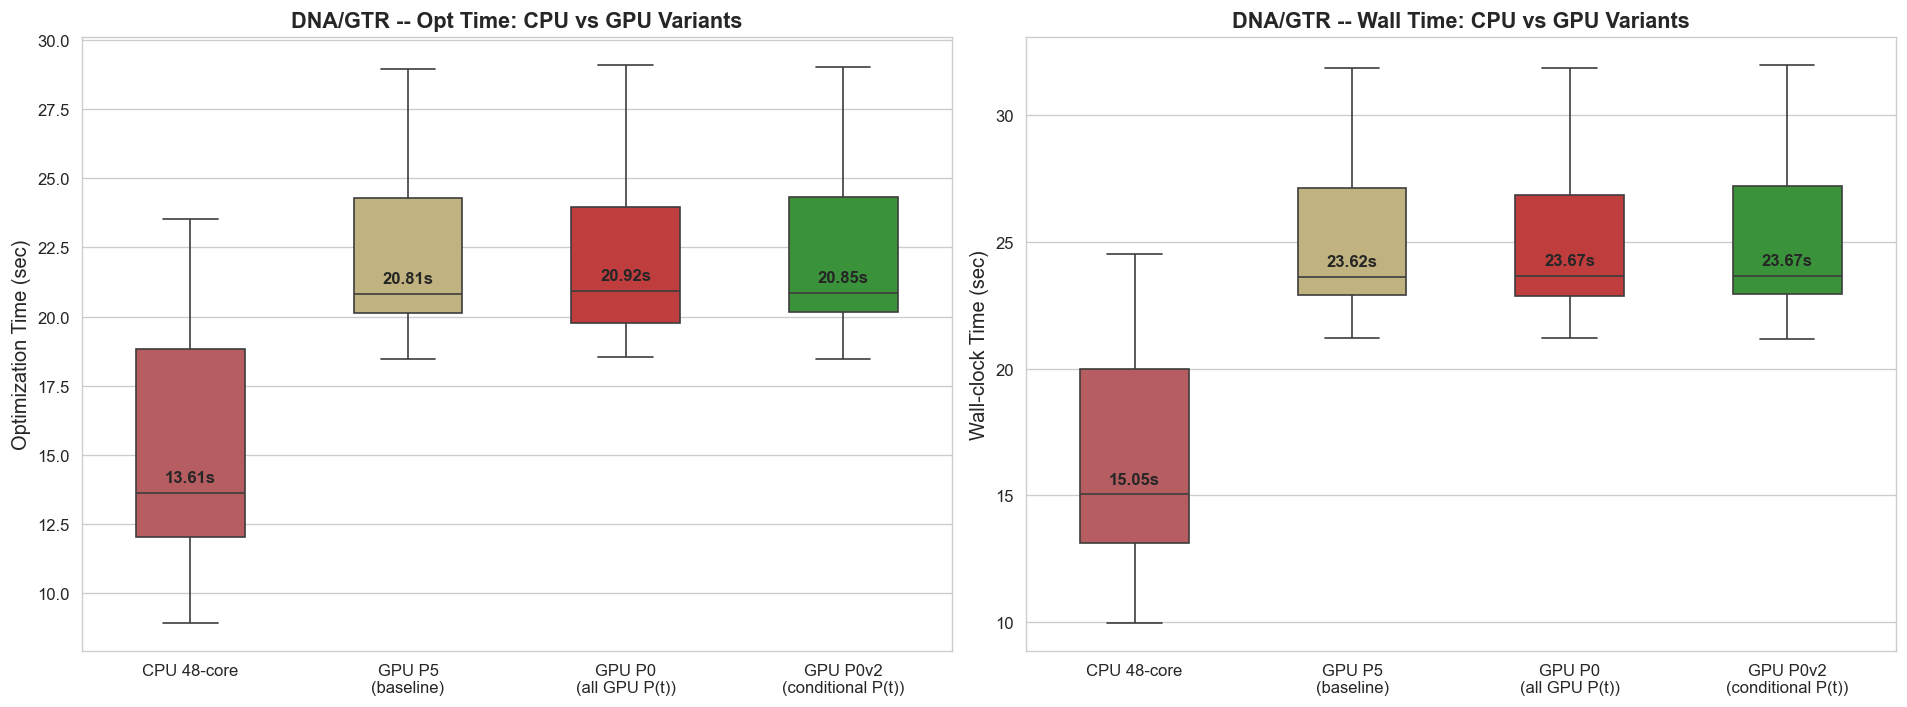

Saved: full_comparison_DNA_GTR.png


In [10]:
all_order = ['OMP_48', 'GPU_P5', 'GPU_P0', 'GPU_P0v2']
all_labels = ['CPU 48-core', 'GPU P5\n(baseline)', 'GPU P0\n(all GPU P(t))', 'GPU P0v2\n(conditional P(t))']
all_colors = ['#C44E52', '#CCB974', '#d62728', '#2ca02c']

for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = df[(df['data_type'] == data_type) & (df['model'] == model) &
               df['backend'].isin(all_order)]
    present = [b for b in all_order if b in subset['backend'].unique()]
    p_colors = [all_colors[all_order.index(b)] for b in present]
    p_labels = [all_labels[all_order.index(b)] for b in present]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.boxplot(data=subset, x='backend', y='opt_time',
               order=present, palette=p_colors, ax=ax1, width=0.5)
    ax1.set_xticklabels(p_labels, fontsize=10)
    ax1.set_ylabel('Optimization Time (sec)', fontsize=12)
    ax1.set_xlabel('')
    ax1.set_title(f'{data_type}/{model} -- Opt Time: CPU vs GPU Variants', fontsize=13, fontweight='bold')
    medians = subset.groupby('backend')['opt_time'].median()
    for i, b in enumerate(present):
        if b in medians.index:
            ax1.text(i, medians[b] + 0.3, f'{medians[b]:.2f}s',
                   ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    sns.boxplot(data=subset, x='backend', y='walltime',
               order=present, palette=p_colors, ax=ax2, width=0.5)
    ax2.set_xticklabels(p_labels, fontsize=10)
    ax2.set_ylabel('Wall-clock Time (sec)', fontsize=12)
    ax2.set_xlabel('')
    ax2.set_title(f'{data_type}/{model} -- Wall Time: CPU vs GPU Variants', fontsize=13, fontweight='bold')
    medians_wt = subset.groupby('backend')['walltime'].median()
    for i, b in enumerate(present):
        if b in medians_wt.index:
            ax2.text(i, medians_wt[b] + 0.3, f'{medians_wt[b]:.2f}s',
                   ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    fname = f'full_comparison_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 7. Final Summary + Conclusions

In [11]:
final = df.groupby(['data_type', 'model', 'backend']).agg(
    walltime_median=('walltime', 'median'),
    opt_time_median=('opt_time', 'median'),
    overhead_median=('overhead', 'median'),
    mean_logl=('log_likelihood', 'mean'),
    n_runs=('walltime', 'count')
).round(2).reset_index()

for ref_name, ref_backend in [('vs_cpu48', 'OMP_48'), ('vs_P0', 'GPU_P0'), ('vs_P5', 'GPU_P5')]:
    ref = final[final['backend'] == ref_backend][['data_type', 'model', 'opt_time_median']].rename(
        columns={'opt_time_median': 'ref'})
    final = final.merge(ref, on=['data_type', 'model'], how='left')
    final[f'opt_speedup_{ref_name}'] = (final['ref'] / final['opt_time_median']).round(3)
    final.drop(columns='ref', inplace=True)

final.to_csv(SAVE_DIR / 'final_summary.csv', index=False)
display(final)

,data_type,model,backend,walltime_median,opt_time_median,overhead_median,mean_logl,n_runs,opt_speedup_vs_cpu48,opt_speedup_vs_P0,opt_speedup_vs_P5
0,AA,LG,GPU_P0,18.27,15.40,2.88,-86311921.52,96,0.882,1.000,1.000
1,AA,LG,GPU_P0v2,18.26,15.38,2.86,-86320131.87,98,0.884,1.001,1.001
2,AA,LG,GPU_P5,18.29,15.40,2.86,-86324112.64,99,0.882,1.000,1.000
3,AA,LG,OMP_10,38.56,37.32,1.28,-86328013.80,100,0.364,0.413,0.413
4,AA,LG,OMP_48,15.02,13.59,1.39,-86328013.80,100,1.000,1.133,1.133
5,AA,LG,VANILA,250.29,247.28,2.99,-89703067.78,20,0.055,0.062,0.062
6,DNA,GTR,GPU_P0,23.67,20.92,2.80,-66545174.85,79,0.651,1.000,0.995
7,DNA,GTR,GPU_P0v2,23.67,20.85,2.81,-66557528.13,80,0.653,1.003,0.998
8,DNA,GTR,GPU_P5,23.62,20.81,2.80,-66557528.13,80,0.654,1.005,1.000
9,DNA,GTR,OMP_10,34.24,33.17,1.08,-67437010.89,100,0.410,0.631,0.627


In [12]:
print('=' * 80)
print('CONCLUSIONS -- P0v2 Branch-Conditional P(t) Computation')
print('=' * 80)

# Correctness
range_check = df.groupby(['data_type', 'model', 'tree']).agg(
    logl_range=('log_likelihood', lambda x: x.max() - x.min())
).reset_index()
max_range = range_check['logl_range'].max()
print(f'\nLIKELIHOOD VERIFICATION:')
print(f'  Max log-likelihood range across any tree: {max_range}')
if max_range < 0.01:
    print('  \u2705 ALL BACKENDS PRODUCE IDENTICAL LOG-LIKELIHOODS.')
    print('  \u2705 P0v2 IS CORRECT.')
else:
    print('  \u274c WARNING: Some trees have likelihood mismatches!')
    display(range_check[range_check['logl_range'] > 0.01])

# Underflow check
total_underflow = df_p0v2['n_underflow'].sum() if 'n_underflow' in df_p0v2.columns else -1
print(f'\nNUMERICAL STABILITY:')
print(f'  Total underflow warnings: {total_underflow}')
if total_underflow == 0:
    print('  \u2705 No numerical underflow \u2014 P0v2 is numerically stable.')

# Performance
print(f'\nPERFORMANCE (opt_time medians):')
for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    p5_opt = df[(df['data_type'] == data_type) & (df['backend'] == 'GPU_P5')]['opt_time'].median()
    p0_opt = df[(df['data_type'] == data_type) & (df['backend'] == 'GPU_P0')]['opt_time'].median()
    p0v2_opt = df[(df['data_type'] == data_type) & (df['backend'] == 'GPU_P0v2')]['opt_time'].median()
    cpu48_opt = df[(df['data_type'] == data_type) & (df['backend'] == 'OMP_48')]['opt_time'].median()
    
    vals = []
    if not np.isnan(p5_opt): vals.append(f'P5={p5_opt:.2f}s')
    if not np.isnan(p0_opt):
        change_p0 = (p0_opt - p5_opt) / p5_opt * 100
        vals.append(f'P0={p0_opt:.2f}s ({change_p0:+.1f}%)')
    if not np.isnan(p0v2_opt):
        change_v2 = (p0v2_opt - p5_opt) / p5_opt * 100
        vals.append(f'P0v2={p0v2_opt:.2f}s ({change_v2:+.1f}%)')
    if not np.isnan(p0v2_opt) and not np.isnan(cpu48_opt):
        vs_cpu = p0v2_opt / cpu48_opt
        vals.append(f'vs CPU48: {vs_cpu:.2f}x')
    print(f'  {data_type}/{model}: {" -> ".join(vals)}')

print(f'\nDNA REGRESSION FIX:')
dna_p0 = df[(df['data_type'] == 'DNA') & (df['backend'] == 'GPU_P0')]['opt_time'].median()
dna_p0v2 = df[(df['data_type'] == 'DNA') & (df['backend'] == 'GPU_P0v2')]['opt_time'].median()
dna_p5 = df[(df['data_type'] == 'DNA') & (df['backend'] == 'GPU_P5')]['opt_time'].median()
if not np.isnan(dna_p0) and not np.isnan(dna_p0v2) and not np.isnan(dna_p5):
    p0_vs_p5 = (dna_p0 - dna_p5) / dna_p5 * 100
    p0v2_vs_p5 = (dna_p0v2 - dna_p5) / dna_p5 * 100
    p0v2_vs_p0 = (dna_p0v2 - dna_p0) / dna_p0 * 100
    print(f'  DNA/GTR P0 vs P5:   {p0_vs_p5:+.2f}% (regression)')
    print(f'  DNA/GTR P0v2 vs P5: {p0v2_vs_p5:+.2f}% (fixed?)')
    print(f'  DNA/GTR P0v2 vs P0: {p0v2_vs_p0:+.2f}% (improvement)')

print(f'\n{"=" * 80}')
print('P0v2 uses branch-conditional P(t) computation:')
print('  TIP-INTERNAL: host model->computeTransDerv() + update device (no download)')
print('  INTERNAL-INTERNAL: GPU computeTransDerivOnGPU() (no host copy needed)')
print('Eliminates the update self() GPU->host download that caused DNA regression.')

CONCLUSIONS -- P0v2 Branch-Conditional P(t) Computation

LIKELIHOOD VERIFICATION:
  Max log-likelihood range across any tree: 0.0
  ✅ ALL BACKENDS PRODUCE IDENTICAL LOG-LIKELIHOODS.
  ✅ P0v2 IS CORRECT.

NUMERICAL STABILITY:
  Total underflow warnings: 0
  ✅ No numerical underflow — P0v2 is numerically stable.

PERFORMANCE (opt_time medians):
  AA/LG: P5=15.40s -> P0=15.39s (-0.0%) -> P0v2=15.38s (-0.1%) -> vs CPU48: 1.13x
  DNA/GTR: P5=20.81s -> P0=20.92s (+0.5%) -> P0v2=20.85s (+0.2%) -> vs CPU48: 1.53x

DNA REGRESSION FIX:
  DNA/GTR P0 vs P5:   +0.54% (regression)
  DNA/GTR P0v2 vs P5: +0.19% (fixed?)
  DNA/GTR P0v2 vs P0: -0.35% (improvement)

P0v2 uses branch-conditional P(t) computation:
  TIP-INTERNAL: host model->computeTransDerv() + update device (no download)
  INTERNAL-INTERNAL: GPU computeTransDerivOnGPU() (no host copy needed)
Eliminates the update self() GPU->host download that caused DNA regression.
